# Processus de diffusion direct (forward) — vérification visuelle

Vérifie visuellement le bruitage progressif `q(x_t | x_0)` implémenté from scratch dans `src/models/ddpm/diffusion.py`, et que `x_T` est proche d'un bruit gaussien pur (checklist "Processus de diffusion (forward)" de `TASKS.md`).

In [1]:
import sys
from pathlib import Path

sys.path.insert(0, str(Path.cwd().parent))

import matplotlib.pyplot as plt
import torch

from src.data.dataset import get_dataloaders, load_config
from src.models.ddpm.diffusion import GaussianDiffusion
from src.utils.seed import set_seed

set_seed(42)

data_config = load_config(Path.cwd().parent / "configs" / "data.yaml")
ddpm_config = load_config(Path.cwd().parent / "configs" / "ddpm_base.yaml")

diffusion = GaussianDiffusion(
    timesteps=ddpm_config["timesteps"],
    schedule=ddpm_config["schedule"],
    beta_start=ddpm_config["beta_start"],
    beta_end=ddpm_config["beta_end"],
)
print(f"T={diffusion.timesteps}, schedule={ddpm_config['schedule']}")

T=1000, schedule=linear


In [2]:
train_loader, _, _ = get_dataloaders(data_config)
batch_x, batch_y = next(iter(train_loader))
images = batch_x[:4]  # 4 images d'exemple, déjà normalisées dans [-1, 1]
print(images.shape, images.min().item(), images.max().item())

torch.Size([4, 1, 32, 32]) -1.0 1.0


## Bruitage progressif sur quelques images

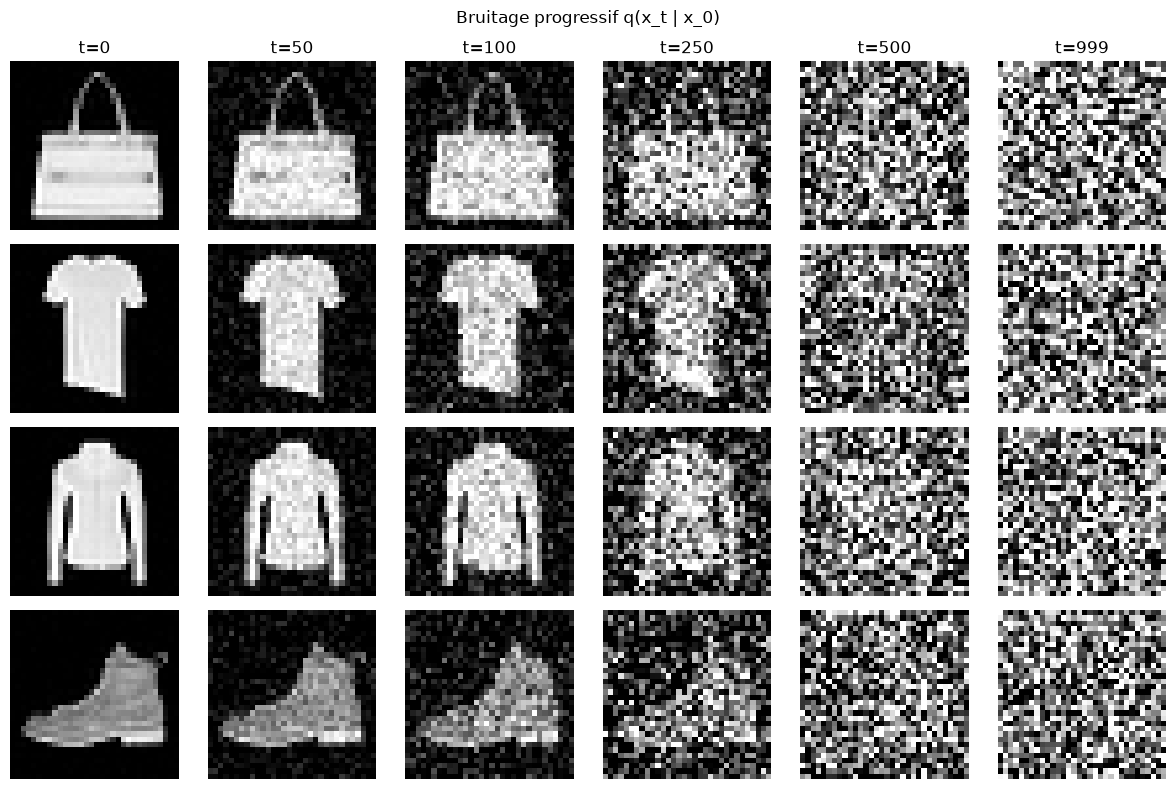

In [3]:
steps_to_show = [0, 50, 100, 250, 500, 999]
fig, axes = plt.subplots(len(images), len(steps_to_show), figsize=(2 * len(steps_to_show), 2 * len(images)))

for row, x0 in enumerate(images):
    x0 = x0.unsqueeze(0)
    for col, t_val in enumerate(steps_to_show):
        t = torch.tensor([t_val])
        x_t = diffusion.q_sample(x0, t)
        ax = axes[row, col]
        ax.imshow(x_t[0, 0].numpy(), cmap="gray", vmin=-1, vmax=1)
        ax.axis("off")
        if row == 0:
            ax.set_title(f"t={t_val}")
plt.suptitle("Bruitage progressif q(x_t | x_0)")
plt.tight_layout()
plt.show()

On observe la dégradation progressive attendue : l'image reste quasi intacte aux petits `t`, la structure du vêtement disparaît progressivement, et à `t=999` l'image est visuellement indiscernable de bruit blanc.

## Vérification que x_T est proche d'un bruit gaussien pur

x_T : moyenne=-0.0038, écart-type=1.0033 (attendu proche de 0 / 1)


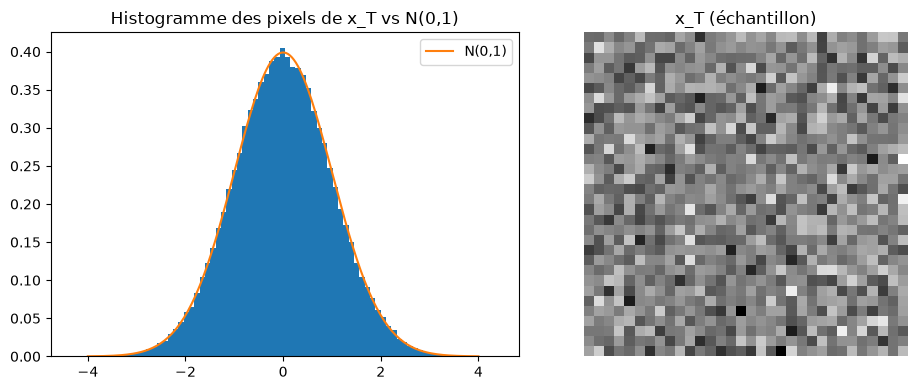

In [4]:
t_last = torch.full((batch_x.shape[0],), diffusion.timesteps - 1)
x_T = diffusion.q_sample(batch_x, t_last)

print(f"x_T : moyenne={x_T.mean().item():.4f}, écart-type={x_T.std().item():.4f} (attendu proche de 0 / 1)")

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
axes[0].hist(x_T.flatten().numpy(), bins=80, density=True)
xs = torch.linspace(-4, 4, 200)
axes[0].plot(xs, torch.exp(-xs**2 / 2) / (2 * torch.pi) ** 0.5, label="N(0,1)")
axes[0].set_title("Histogramme des pixels de x_T vs N(0,1)")
axes[0].legend()

axes[1].imshow(x_T[0, 0].numpy(), cmap="gray")
axes[1].set_title("x_T (échantillon)")
axes[1].axis("off")
plt.tight_layout()
plt.show()

## Observations

- Le bruitage progressif se comporte comme attendu (formule fermée `q(x_t | x_0)`, sans boucle) : dégradation lente au début, rapide autour du milieu du schedule, puis stabilisation en bruit pur.
- À `t = T-1 = 999`, la distribution des pixels de `x_T` colle à `N(0, 1)` (moyenne et écart-type proches de 0/1, histogramme superposable à la gaussienne théorique) — confirmé aussi par `tests/test_diffusion.py::test_x_T_close_to_standard_gaussian`.
- Schedule retenu pour la baseline : `linear`, `beta_start=1e-4`, `beta_end=0.02`, `T=1000` (Ho et al. 2020). Le schedule `cosine` est implémenté et testé mais non utilisé en baseline — à comparer plus tard si le temps le permet.